In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request

In [171]:
# Download the two official UCI files

train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

print("Dataset downloaded successfully")

Dataset downloaded successfully


In [180]:
train_df = pd.read_csv("data/adult.data",names=columns,skipinitialspace=True)

print("Train data loaded")

Train data loaded


In [181]:
test_df = pd.read_csv("data/adult.test",names=columns,skipinitialspace=True,skiprows=1)

print("Test data loaded")

Test data loaded


In [182]:
# Add source information

train_df["source_split"] = "train"
test_df["source_split"] = "test"

# Combine both files

df = pd.concat([train_df, test_df], ignore_index=True)

print("Dataset combined successfully")
print("Shape:", df.shape)

Dataset combined successfully
Shape: (48842, 16)


In [183]:
# Display first 5 rows

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source_split
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train


In [186]:
# Number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 48842
Columns: 16


In [187]:
# Column names

df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income', 'source_split'],
      dtype='object')

In [188]:
# Data types

df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
source_split      object
dtype: object

In [189]:
# Check missing values

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
source_split      0
dtype: int64

In [190]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 29


In [191]:
# Save original dataset before cleaning

df.to_csv("data/adult_income_uncleaned.csv", index=False)

print("Uncleaned dataset saved successfully")

Uncleaned dataset saved successfully


# Data Cleaning

In [192]:
# Remove spaces from text columns

for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

print("Extra spaces removed")

Extra spaces removed


In [193]:
# Replace ? with NaN

df = df.replace("?", np.nan)

print("Missing values identified")

Missing values identified


In [194]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     857
income               0
source_split         0
dtype: int64

In [195]:
# Fill missing categorical values

df["workclass"] = df["workclass"].fillna("Unknown")
df["occupation"] = df["occupation"].fillna("Unknown")
df["native_country"] = df["native_country"].fillna("Unknown")

print("Missing categorical values handled")

Missing categorical values handled


In [196]:
# Convert columns to numeric

df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["fnlwgt"] = pd.to_numeric(df["fnlwgt"], errors="coerce")
df["education_num"] = pd.to_numeric(df["education_num"], errors="coerce")
df["capital_gain"] = pd.to_numeric(df["capital_gain"], errors="coerce")
df["capital_loss"] = pd.to_numeric(df["capital_loss"], errors="coerce")
df["hours_per_week"] = pd.to_numeric(df["hours_per_week"], errors="coerce")

print("Numeric columns converted")

Numeric columns converted


In [200]:
# Remove rows with impossible values

df = df[(df["age"] > 0) &(df["hours_per_week"] >= 0) &(df["education_num"] >= 0)]

print("Invalid rows removed")

Invalid rows removed


In [201]:
# Clean income labels

df["income"] = df["income"].str.replace(".", "", regex=False)
df["income"] = df["income"].str.strip()

df["income"].value_counts()

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [242]:
# 1 means income above $50K
# 0 means income $50K or below

df["high_income"] = np.where(df["income"] == ">50K",1, 0)

df[["income", "high_income"]].head()

,income,high_income
0,<=50K,0
1,<=50K,0
2,<=50K,0
3,<=50K,0
4,<=50K,0


In [243]:
# Create age groups

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"
    ]
)

df["age_group"].value_counts()

age_group
26-35    12713
36-45    11947
18-25     9614
46-55     8292
56-65     4445
66+       1802
Name: count, dtype: int64

In [244]:
# Create working hour groups

df["hours_group"] = pd.cut(
    df["hours_per_week"],
    bins=[0, 20, 40, 60, 100],
    labels=[
        "0-20 Hours",
        "21-40 Hours",
        "41-60 Hours",
        "61+ Hours"
    ],
    include_lowest=True
)

df["hours_group"].value_counts()

hours_group
21-40 Hours    30018
41-60 Hours    12671
0-20 Hours      4448
61+ Hours       1676
Name: count, dtype: int64

In [245]:
# Calculate net capital

df["net_capital"] = (
    df["capital_gain"] - df["capital_loss"]
)
df[[
    "capital_gain",
    "capital_loss",
    "net_capital"
]].head()

,capital_gain,capital_loss,net_capital
0,2174,0,2174
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [246]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Final dataset shape: (48813, 20)

Missing values:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
source_split      0
high_income       0
age_group         0
hours_group       0
net_capital       0
dtype: int64

Duplicate rows: 0


In [247]:
df = df.drop_duplicates()

In [248]:
df.duplicated().sum()

0

In [249]:
# Display cleaned data

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,source_split,high_income,age_group,hours_group,net_capital
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,train,0,36-45,21-40 Hours,2174
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,train,0,46-55,0-20 Hours,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,train,0,36-45,21-40 Hours,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,train,0,46-55,21-40 Hours,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,train,0,26-35,21-40 Hours,0


In [250]:
# Save cleaned dataset

df.to_csv(
    "data/adult_income_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


# Exploratory Data Ananlysis

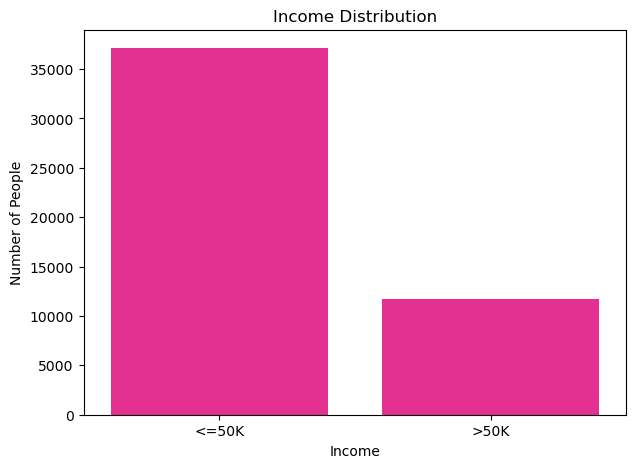

In [251]:
# Income Distribution
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="income",color="DeepPink")

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of People")

plt.show()

In [252]:
income_percentage = df["income"].value_counts(normalize=True) * 100

print(income_percentage)

income
<=50K    76.061705
>50K     23.938295
Name: proportion, dtype: float64


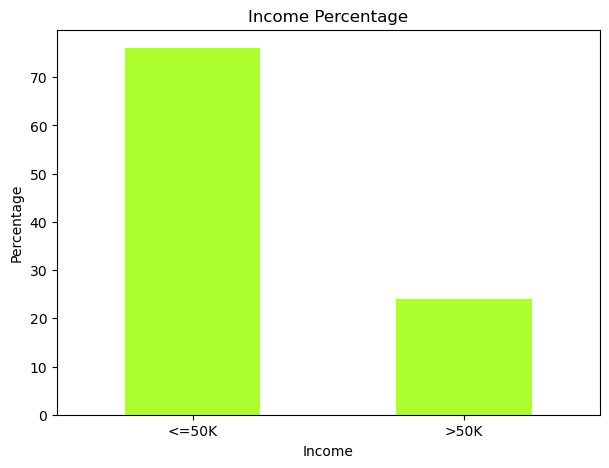

In [253]:
# Income Percentage
plt.figure(figsize=(7, 5))

income_percentage.plot(kind="bar",color="GreenYellow")

plt.title("Income Percentage")
plt.xlabel("Income")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

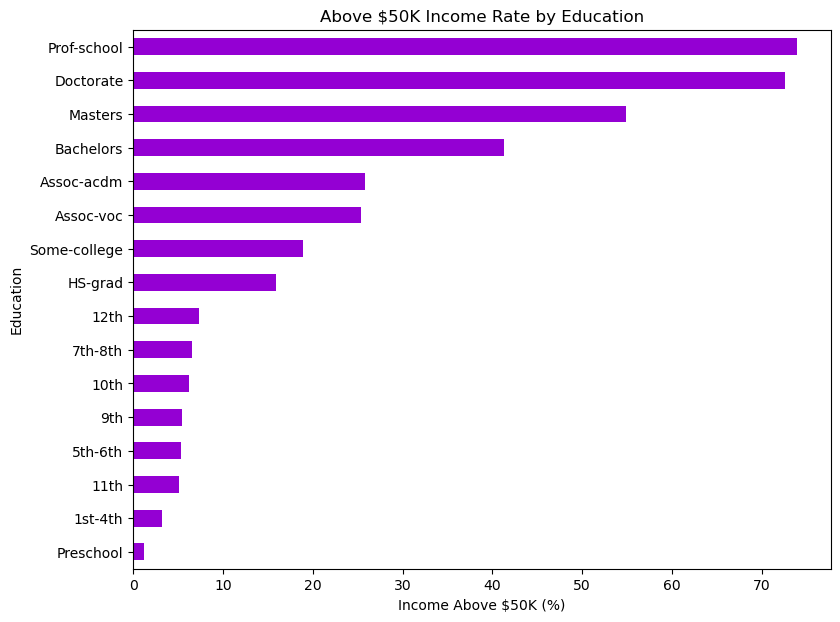

In [254]:
# Above $50K Income Rate by Education

education_income = (
    df.groupby("education")["high_income"]
    .mean() * 100
)

education_income = education_income.sort_values()

plt.figure(figsize=(9, 7))

education_income.plot(kind="barh", color="DarkViolet")

plt.title("Above $50K Income Rate by Education")
plt.xlabel("Income Above $50K (%)")
plt.ylabel("Education")

plt.show()

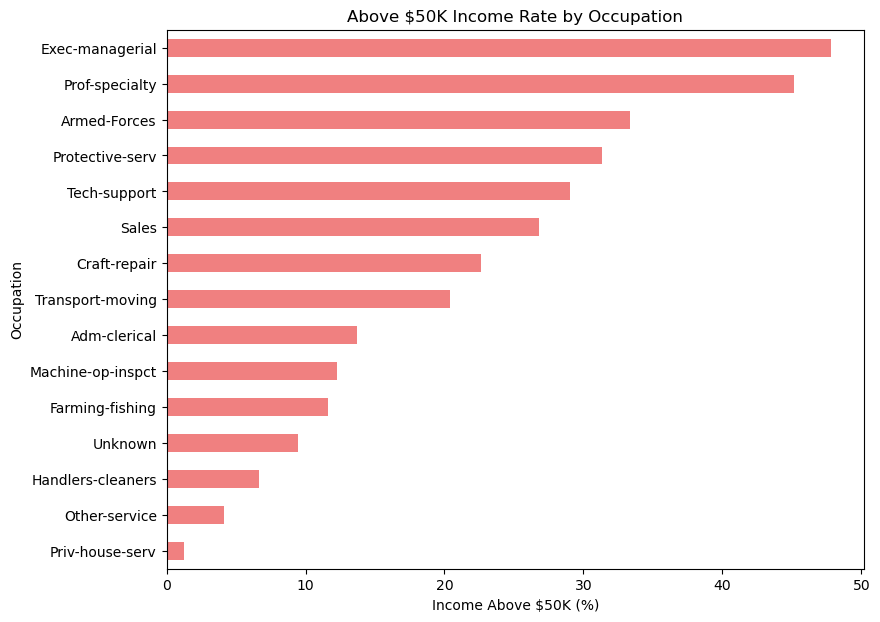

In [255]:
# Above $50K Income Rate by Occupation

occupation_income = (
    df.groupby("occupation")["high_income"]
    .mean() * 100
)

occupation_income = occupation_income.sort_values()

plt.figure(figsize=(9, 7))

occupation_income.plot(kind="barh", color="LightCoral")

plt.title("Above $50K Income Rate by Occupation")
plt.xlabel("Income Above $50K (%)")
plt.ylabel("Occupation")

plt.show()

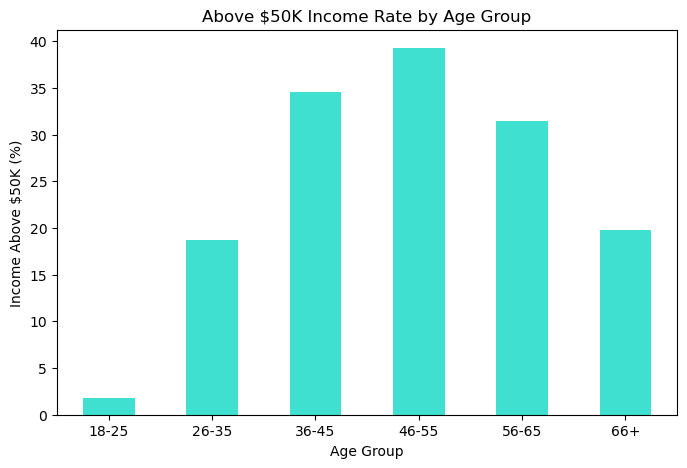

In [256]:
# Above $50K Income Rate by Age Group
age_income = (
    df.groupby("age_group", observed=True)["high_income"]
    .mean() * 100
)

plt.figure(figsize=(8, 5))

age_income.plot(kind="bar", color="Turquoise")

plt.title("Above $50K Income Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Income Above $50K (%)")

plt.xticks(rotation=0)

plt.show()

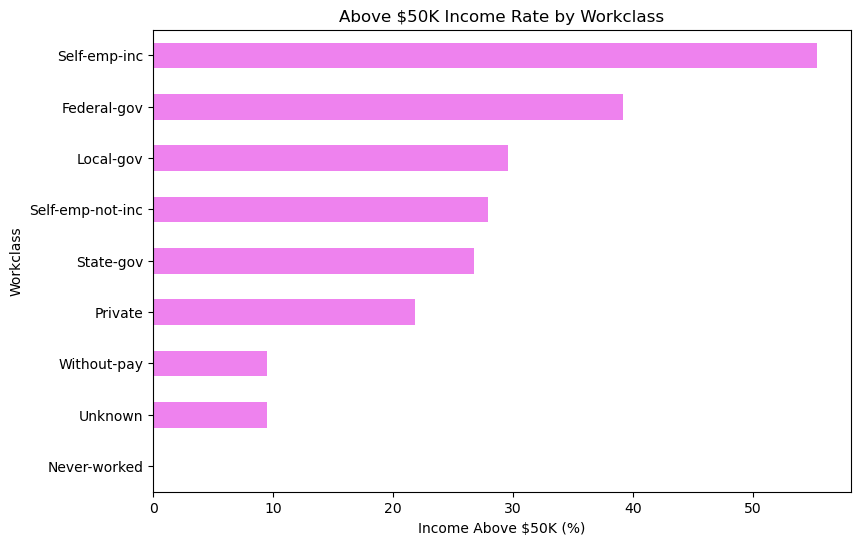

In [257]:
#Above $50K Income Rate by Workclass

workclass_income = (
    df.groupby("workclass")["high_income"]
    .mean() * 100
)

workclass_income = workclass_income.sort_values()

plt.figure(figsize=(9, 6))

workclass_income.plot(kind="barh", color="Violet")

plt.title("Above $50K Income Rate by Workclass")
plt.xlabel("Income Above $50K (%)")
plt.ylabel("Workclass")

plt.show()

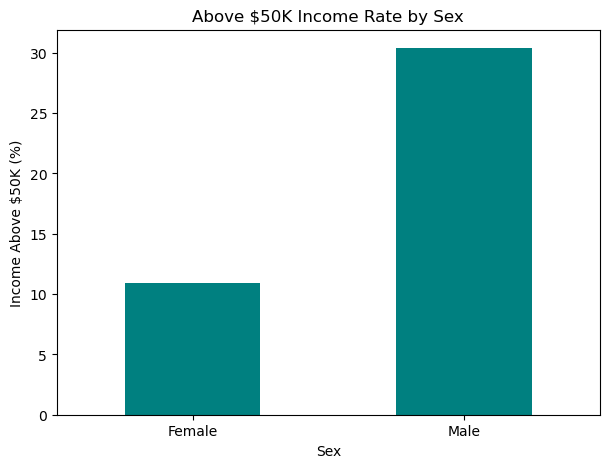

In [258]:
# Above $50K Income Rate by Sex
sex_income = (
    df.groupby("sex")["high_income"]
    .mean() * 100
)

plt.figure(figsize=(7, 5))

sex_income.plot(kind="bar", color="Teal")

plt.title("Above $50K Income Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Income Above $50K (%)")

plt.xticks(rotation=0)

plt.show()

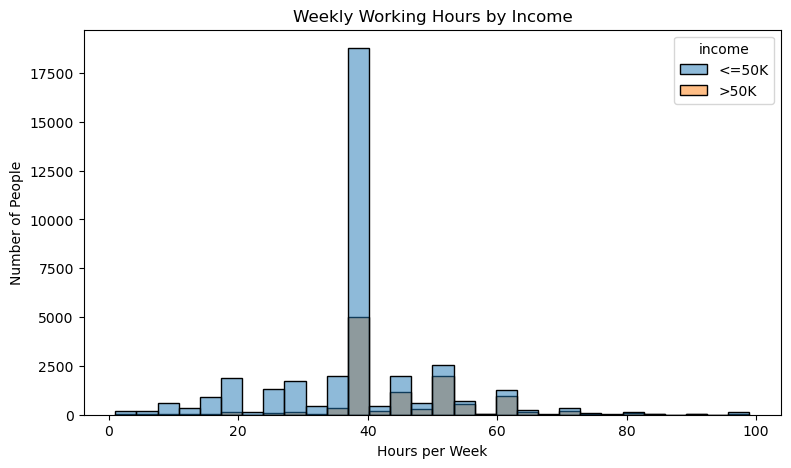

In [259]:
# Weekly Working Hours by Income

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="hours_per_week",
    hue="income",
    bins=30,
)

plt.title("Weekly Working Hours by Income")
plt.xlabel("Hours per Week")
plt.ylabel("Number of People")

plt.show()

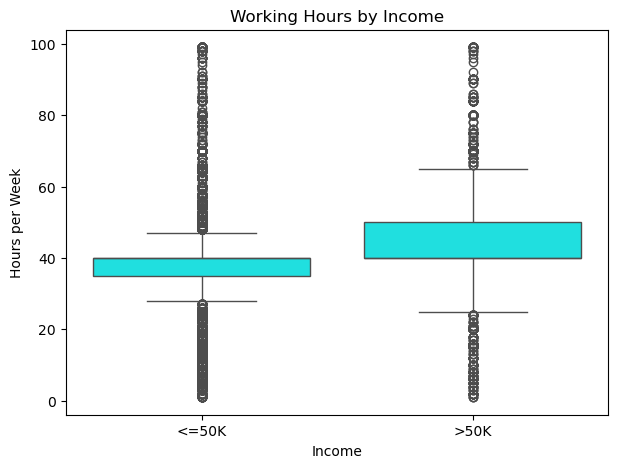

In [260]:
# Working Hours by Income
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="income",
    y="hours_per_week",
    color="Aqua"
)

plt.title("Working Hours by Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")

plt.show()

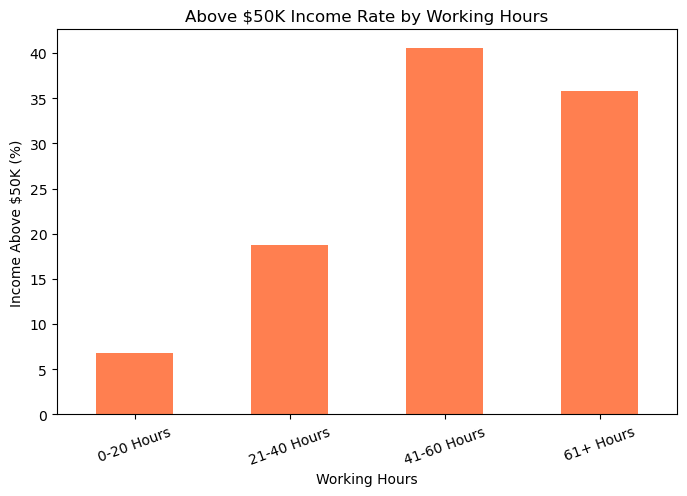

In [261]:
# Above $50K Income Rate by Working Hours
hours_income = (
    df.groupby("hours_group", observed=True)["high_income"]
    .mean() * 100
)

plt.figure(figsize=(8, 5))

hours_income.plot(kind="bar", color="Coral")

plt.title("Above $50K Income Rate by Working Hours")
plt.xlabel("Working Hours")
plt.ylabel("Income Above $50K (%)")

plt.xticks(rotation=20)

plt.show()

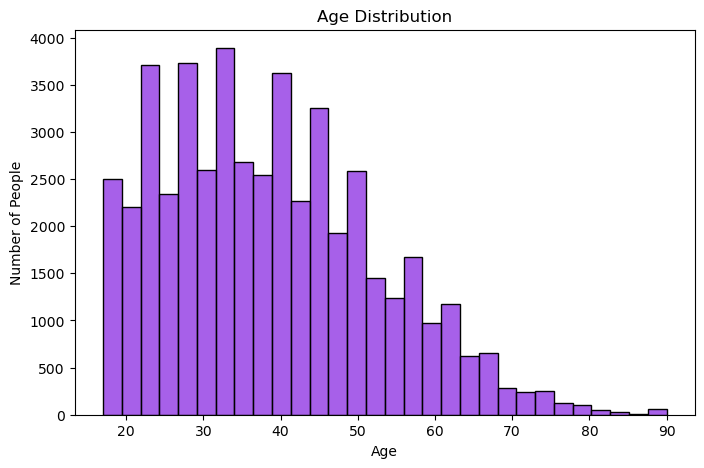

In [262]:
# Age Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    color="BlueViolet"
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.show()

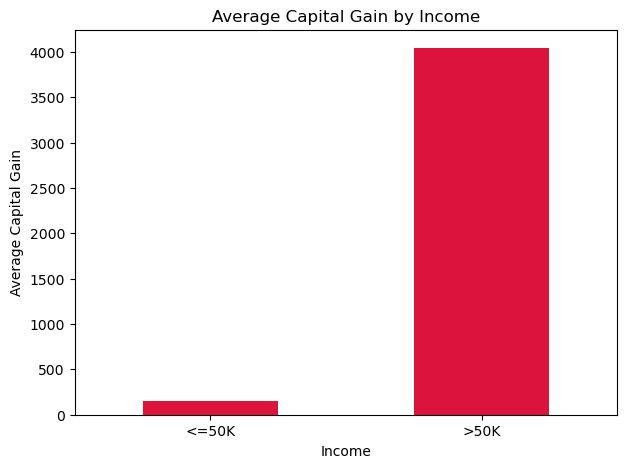

In [263]:
capital_gain_income = (
    df.groupby("income")["capital_gain"]
    .mean()
)

plt.figure(figsize=(7, 5))

capital_gain_income.plot(kind="bar",color="Crimson")

plt.title("Average Capital Gain by Income")
plt.xlabel("Income")
plt.ylabel("Average Capital Gain")

plt.xticks(rotation=0)

plt.show()

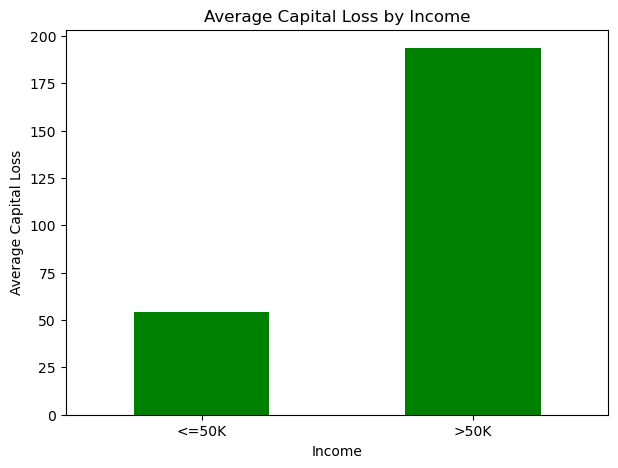

In [264]:
capital_loss_income = (
    df.groupby("income")["capital_loss"]
    .mean()
)

plt.figure(figsize=(7, 5))

capital_loss_income.plot(kind="bar",color="green")

plt.title("Average Capital Loss by Income")
plt.xlabel("Income")
plt.ylabel("Average Capital Loss")

plt.xticks(rotation=0)

plt.show()

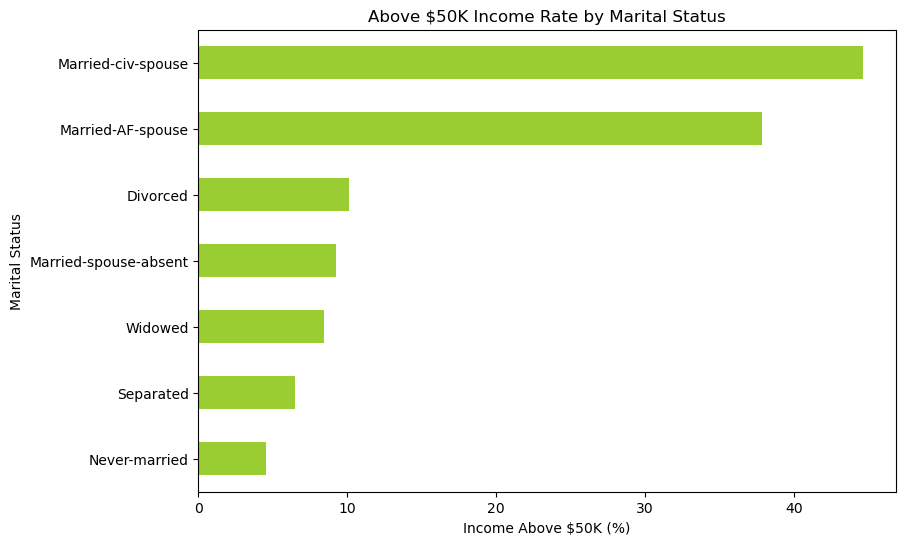

In [265]:
marital_income = (
    df.groupby("marital_status")["high_income"]
    .mean() * 100
)

marital_income = marital_income.sort_values()

plt.figure(figsize=(9, 6))

marital_income.plot(kind="barh", color="yellowgreen")

plt.title("Above $50K Income Rate by Marital Status")
plt.xlabel("Income Above $50K (%)")
plt.ylabel("Marital Status")

plt.show()

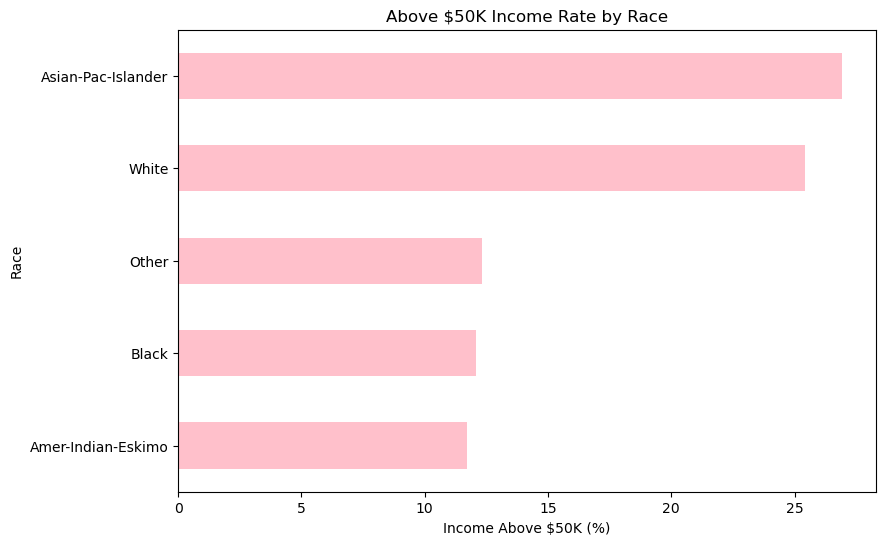

In [266]:
race_income = (
    df.groupby("race")["high_income"]
    .mean() * 100
)

race_income = race_income.sort_values()

plt.figure(figsize=(9, 6))

race_income.plot(kind="barh",color="pink")

plt.title("Above $50K Income Rate by Race")
plt.xlabel("Income Above $50K (%)")
plt.ylabel("Race")

plt.show()

In [267]:
numeric_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "high_income"
]

correlation = df[numeric_columns].corr()

print(correlation)

                     age    fnlwgt  education_num  capital_gain  capital_loss  \
age             1.000000 -0.076474       0.030760      0.077221      0.056908   
fnlwgt         -0.076474  1.000000      -0.038798     -0.003713     -0.004375   
education_num   0.030760 -0.038798       1.000000      0.125186      0.080969   
capital_gain    0.077221 -0.003713       0.125186      1.000000     -0.031460   
capital_loss    0.056908 -0.004375       0.080969     -0.031460      1.000000   
hours_per_week  0.071322 -0.013516       0.143872      0.082154      0.054440   
high_income     0.230335 -0.006376       0.332746      0.223014      0.147527   

                hours_per_week  high_income  
age                   0.071322     0.230335  
fnlwgt               -0.013516    -0.006376  
education_num         0.143872     0.332746  
capital_gain          0.082154     0.223014  
capital_loss          0.054440     0.147527  
hours_per_week        1.000000     0.227649  
high_income           0.22764

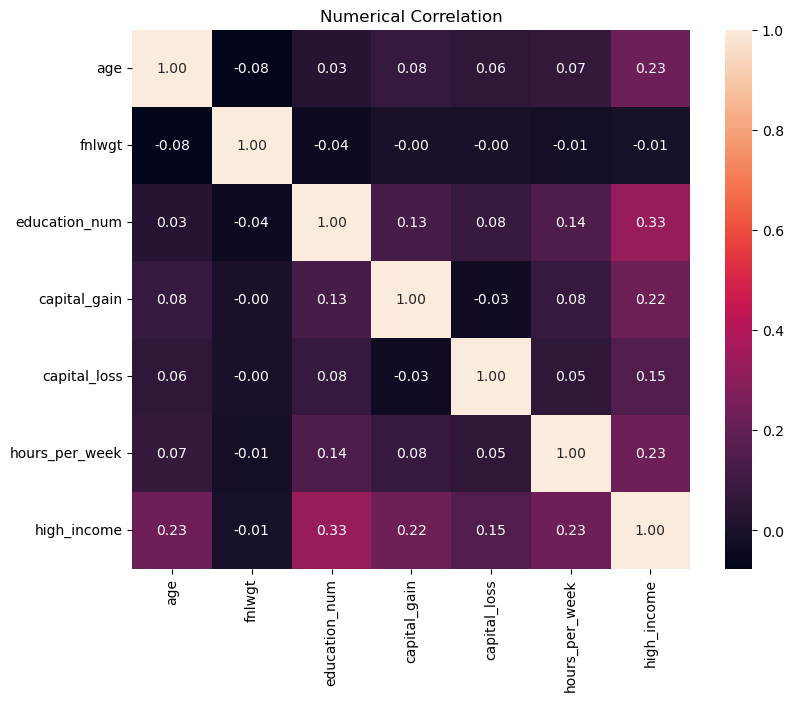

In [268]:
# Numerical Correlation
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Numerical Correlation")

plt.show()

In [269]:
income_summary = df["income"].value_counts()

print(income_summary)

income
<=50K    37128
>50K     11685
Name: count, dtype: int64


In [270]:
print(education_income.sort_values(ascending=False))

education
Prof-school     73.980815
Doctorate       72.558923
Masters         54.932229
Bachelors       41.309227
Assoc-acdm      25.796377
Assoc-voc       25.339806
Some-college    18.971387
HS-grad         15.858528
12th             7.317073
7th-8th          6.498952
10th             6.263499
9th              5.423280
5th-6th          5.314961
11th             5.077263
1st-4th          3.265306
Preschool        1.219512
Name: high_income, dtype: float64


In [271]:
print(occupation_income.sort_values(ascending=False))

occupation
Exec-managerial      47.797502
Prof-specialty       45.127290
Armed-Forces         33.333333
Protective-serv      31.332655
Tech-support         29.065744
Sales                26.798692
Craft-repair         22.646144
Transport-moving     20.424628
Adm-clerical         13.694722
Machine-op-inspct    12.288837
Farming-fishing      11.634163
Unknown               9.433962
Handlers-cleaners     6.663448
Other-service         4.147184
Priv-house-serv       1.250000
Name: high_income, dtype: float64


In [272]:
print(age_income.sort_values(ascending=False))

age_group
46-55    39.254703
36-45    34.560978
56-65    31.406074
66+      19.811321
26-35    18.713128
18-25     1.757853
Name: high_income, dtype: float64


In [273]:
print(workclass_income.sort_values(ascending=False))

workclass
Self-emp-inc        55.371901
Federal-gov         39.175978
Local-gov           29.559949
Self-emp-not-inc    27.894328
State-gov           26.754165
Private             21.798164
Without-pay          9.523810
Unknown              9.467667
Never-worked         0.000000
Name: high_income, dtype: float64


In [274]:
print(workclass_income.sort_values(ascending=False))

workclass
Self-emp-inc        55.371901
Federal-gov         39.175978
Local-gov           29.559949
Self-emp-not-inc    27.894328
State-gov           26.754165
Private             21.798164
Without-pay          9.523810
Unknown              9.467667
Never-worked         0.000000
Name: high_income, dtype: float64


## Conclusion

The Adult Income dataset was cleaned and analyzed using Python to understand the characteristics associated with annual income above USD 50K.

The analysis compared income levels across education, occupation, age group, workclass, sex, marital status, relationship, and race. Weekly working hours, education level, capital gain, and capital loss were also analyzed.

The EDA shows that income distribution differs across different demographic, education, and work-related groups. These patterns provide useful information for understanding income distribution in the dataset.

However, this is a descriptive analysis of historical census data. The results show associations and do not prove that education, occupation, age, sex, working hours, or any other characteristic directly causes a person to earn more than USD 50K.

The cleaned dataset can be used as a foundation for future analysis or predictive modeling.
